# Clustering Analysis
Perform K-Means and Hierarchical clustering on the preprocessed customer data.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuration
INPUT_FILE = 'data/customer_info_cleaned.csv'
RANDOM_STATE = 42

# Set plot style
sns.set(style="whitegrid")

## 1. Load Data

In [15]:
df = pd.read_csv(INPUT_FILE)
print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (16978, 23)


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,Age,has_loyalty_card,customer_gender_male
0,-1.072504,0.966614,0.976454,0.824209,-1.184504,-0.901934,0.700516,-0.236398,-0.249669,0.095091,...,-0.338539,0.937665,0.408221,0.805903,-2.301895,-1.155593,-0.474619,1.269162,0.476631,True
1,0.238154,-0.090058,2.062127,0.824209,-1.604511,-0.650226,-0.135117,0.032317,-0.184642,0.639865,...,-2.207893,0.115497,-0.848041,0.521795,0.442280,1.683075,1.015009,0.205934,0.476631,True
2,-1.072504,-1.146731,-0.109220,-0.767580,0.290313,0.723070,-0.552934,0.857676,0.405726,-0.841108,...,-0.371175,0.536702,-0.922565,-0.720614,-0.041986,1.286790,1.078169,-0.857295,0.476631,True
3,-1.072504,-0.090058,-0.109220,0.824209,-0.884446,-0.269721,0.073791,0.129256,-1.405316,-0.257609,...,0.454804,0.202448,-0.028277,-0.047904,1.572235,0.249013,-0.104150,-1.584767,0.476631,True
4,0.893483,-0.090058,0.976454,0.824209,0.867642,0.636863,-0.970751,1.060131,0.751575,0.313075,...,0.289172,-0.329351,1.845471,-0.009794,-1.656207,-0.018443,1.150427,0.765528,0.476631,True


## 2. K-Means Clustering

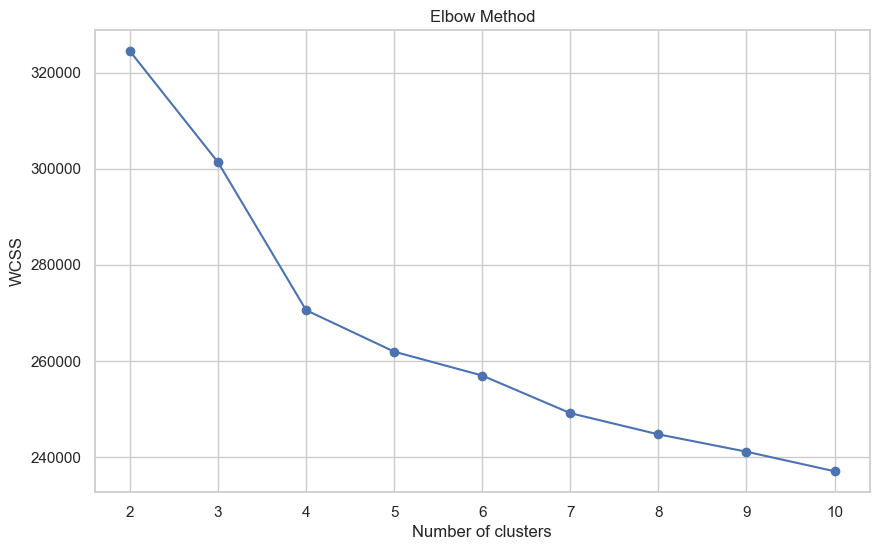

In [16]:
# 2.1 Determine optimal K using Elbow Method
wcss = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_k, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [17]:
# 2.2 Fit K-Means with chosen K
# Based on typical results for this dataset, we'll start with K=4, but this should be adjusted based on the Elbow plot.
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=RANDOM_STATE)
df['kmeans_cluster'] = kmeans.fit_predict(df)

print(f"K-Means clustering completed with K={OPTIMAL_K}")

K-Means clustering completed with K=4


## 3. Hierarchical Clustering

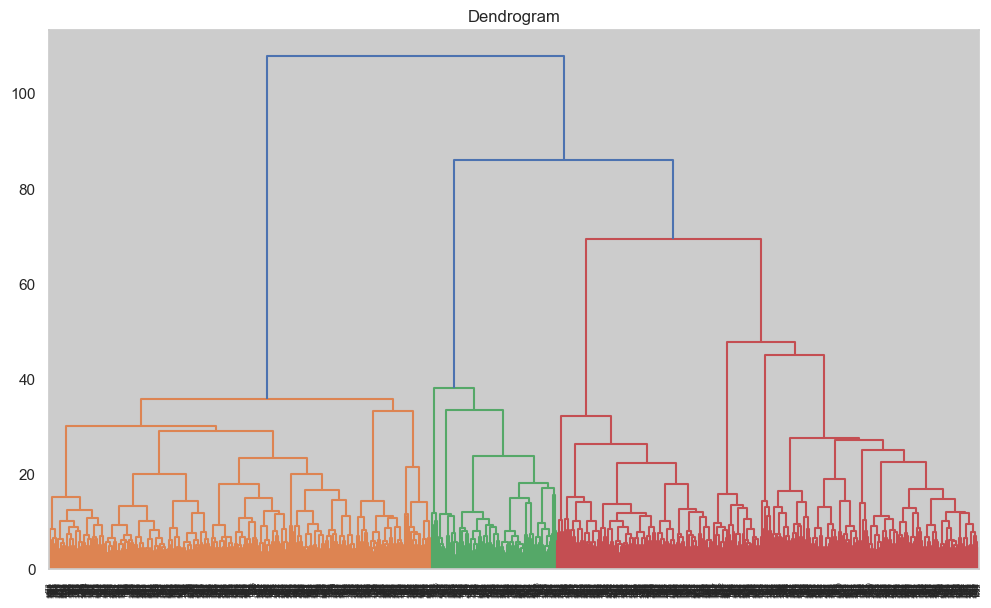

In [18]:
# 3.1 Plot Dendrogram
# We'll use a sample to keep it readable and fast if the dataset is large
sample_df = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE).drop(columns=['kmeans_cluster'], errors='ignore')

plt.figure(figsize=(12, 7))
plt.title("Dendrogram")
dend = dendrogram(linkage(sample_df, method='ward'))
plt.show()

In [19]:
# 3.2 Fit Agglomerative Clustering
# Using the same K as K-Means for comparison, or adjust based on Dendrogram
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['hierarchical_cluster'] = hc.fit_predict(df.drop(columns=['kmeans_cluster'], errors='ignore'))

print(f"Hierarchical clustering completed with K={OPTIMAL_K}")

Hierarchical clustering completed with K=4


## 4. Visualization (PCA)

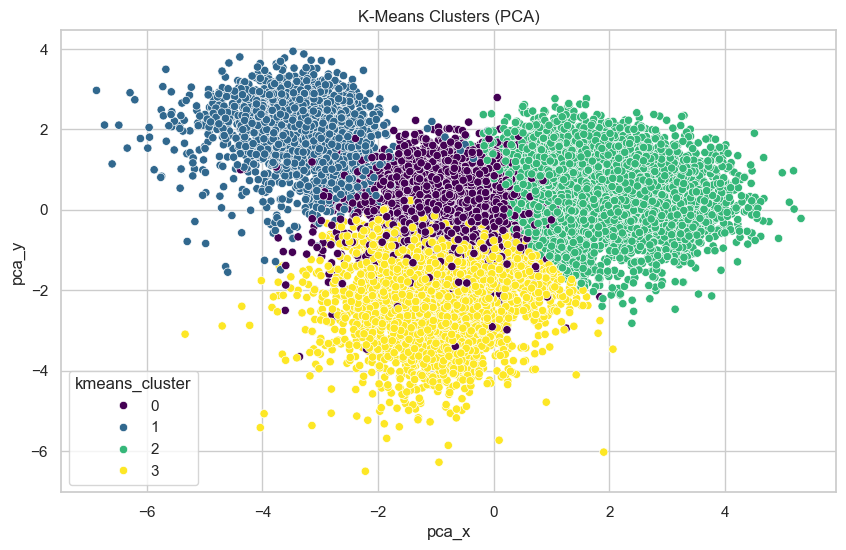

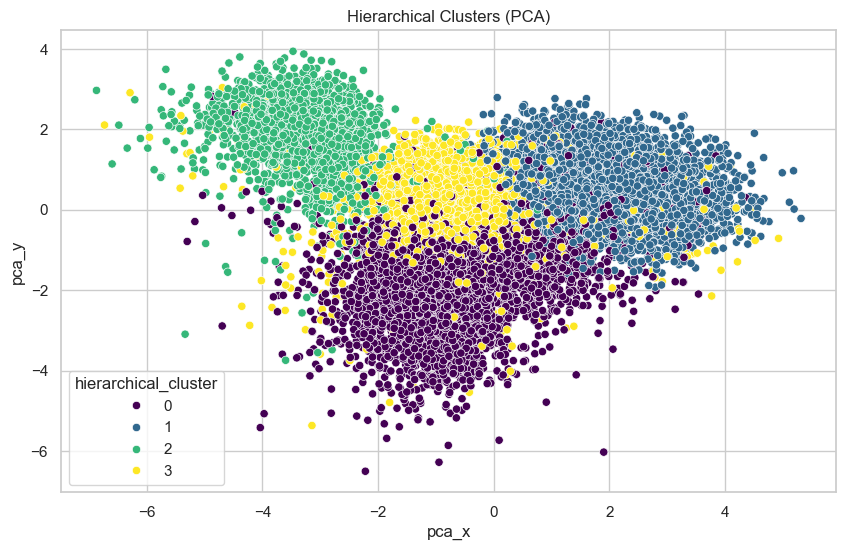

In [20]:
# Reduce to 2 dimensions for visualization
cols_for_pca = df.drop(columns=['kmeans_cluster', 'hierarchical_cluster'], errors='ignore').columns
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df[cols_for_pca])

df['pca_x'] = pca_components[:, 0]
df['pca_y'] = pca_components[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca_x', y='pca_y', hue='kmeans_cluster', data=df, palette='viridis')
plt.title('K-Means Clusters (PCA)')
plt.show()

# Plot Hierarchical Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca_x', y='pca_y', hue='hierarchical_cluster', data=df, palette='viridis')
plt.title('Hierarchical Clusters (PCA)')
plt.show()